# Data Audit & Viability Check
**Objective:** Determine if the dataset supports Causal Dynamic Pricing.
**Inputs:** `calendar.csv`, `listings.csv`

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent dir to path to import pricing_engine
sys.path.append(os.path.abspath('..'))

from pricing_engine.audit import MarketAuditor, AuditThresholds

## 1. Load Data
*Replace paths with your actual file locations*

In [2]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [3]:
df_cal_raw = pd.read_csv(CALENDAR_PATH, dtype=str)
df_list = pd.read_csv(LISTINGS_PATH)

print("Calendar rows:", len(df_cal_raw))
print("Listings rows:", len(df_list))


Calendar rows: 1393570
Listings rows: 3818


In [4]:
print("Raw price samples:")
print(df_cal_raw['price'].dropna().head(10).tolist())


Raw price samples:
['$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00', '$85.00']


## 2. Initialize Auditor & Clean Data

In [5]:
def clean_price_robust(price_series):
    s = price_series.astype(str)
    s = s.str.replace(r'[^\d,.-]', '', regex=True)
    s = s.str.replace(',', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

df_cal_raw['price'] = clean_price_robust(df_cal_raw['price'])


In [6]:
df_cal = df_cal_raw.copy()

# Dates
df_cal['date'] = pd.to_datetime(df_cal['date'], errors='coerce')
df_cal['dow'] = df_cal['date'].dt.dayofweek

# Exposure & censoring
df_cal['exposed'] = (df_cal['available'].str.lower() == 't')

# Action visibility
df_cal['action_observed'] = df_cal['price'].notna()

# Outcome proxy (AUDIT ONLY)
df_cal['is_booked_proxy'] = (df_cal['available'].str.lower() == 'f').astype(int)


In [7]:
# --- Normalize listing_id column safely (CRITICAL) ---

# Calendar: listing_id always comes from calendar.csv
df_cal['listing_id'] = df_cal['listing_id'].astype(str)

# Listings: handle both possible schemas
if 'listing_id' in df_list.columns:
    df_list['listing_id'] = df_list['listing_id'].astype(str)
elif 'id' in df_list.columns:
    df_list['listing_id'] = df_list['id'].astype(str)
else:
    raise KeyError("Neither 'id' nor 'listing_id' found in listings dataframe")

# Merge minimal metadata
df_clean = df_cal.merge(
    df_list[['listing_id', 'neighbourhood_cleansed']],
    on='listing_id',
    how='inner'
)

df_clean = df_clean.rename(columns={'neighbourhood_cleansed': 'neighborhood'})

print("Audit rows after merge:", len(df_clean))


Audit rows after merge: 1393570


In [8]:
assert df_clean['listing_id'].dtype == object
assert not df_clean['listing_id'].isna().any()


In [9]:
print("Action observed rate:", df_clean['action_observed'].mean())
print("Exposure rate:", df_clean['exposed'].mean())
print("Booked proxy rate:", df_clean['is_booked_proxy'].mean())


Action observed rate: 0.6706100160020666
Exposure rate: 0.6706100160020666
Booked proxy rate: 0.32938998399793334


In [10]:
auditor = MarketAuditor(AuditThresholds(
    min_price_std=5.0,
    min_bookings=10,
    min_variance_coverage=0.30,
    min_exposure_days=30
))


## 3. Identifiability Check (Price Variance)
*Do we have enough price movement to learn elasticity?*

In [11]:
id_metrics = auditor.check_identifiability(df_clean)

print("=== IDENTIFIABILITY REPORT ===")
print(f"Listings evaluated: {id_metrics['total_listings_evaluated']}")
print(f"Listings with price variation: {id_metrics['pct_identifiable']:.2%}")
print(f"Decision: {id_metrics['status']}")


2026-01-03 15:03:24,616 - INFO - Checking Identifiability (Observed Price Variance)...


=== IDENTIFIABILITY REPORT ===
Listings evaluated: 3716
Listings with price variation: 43.60%
Decision: PASS


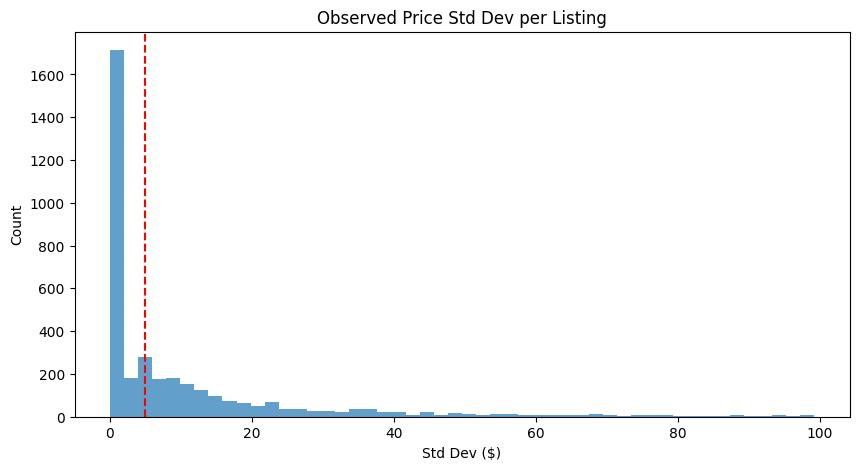

In [12]:
price_std = (
    df_clean[df_clean['action_observed']]
    .groupby('listing_id')['price']
    .std()
)

plt.figure(figsize=(10, 5))
plt.hist(price_std[price_std < 100], bins=50, alpha=0.7)
plt.axvline(auditor.thresh.min_price_std, color='red', linestyle='--')
plt.title("Observed Price Std Dev per Listing")
plt.xlabel("Std Dev ($)")
plt.ylabel("Count")
plt.show()


## 4. Sparsity Check (Cold Start)
*Is the data too sparse for individual models?*

In [15]:
sparsity_metrics = auditor.check_sparsity(df_clean)

print("=== SPARSITY REPORT ===")
print(f"Low exposure listings: {sparsity_metrics['pct_low_exposure']:.2%}")
print(f"observable bookings (proxy): {sparsity_metrics['pct_observable_bookings']:.2%}")
print(f"Recommendation: {sparsity_metrics['recommendation']}")


2026-01-03 15:05:21,091 - INFO - Checking Sparsity (Exposure & Outcome)...


=== SPARSITY REPORT ===
Low exposure listings: 7.39%
observable bookings (proxy): 0.00%
Recommendation: INDEPENDENT_MODELS


In [ ]:
availability_rate = (
    df_clean.groupby('listing_id')['exposed']
    .mean()
)

print("Median availability:", availability_rate.median())


Median availability: 0.8438356164383561


In [ ]:
price_change_rate = (
    df_clean[df_clean['action_observed']]
    .groupby('listing_id')['price']
    .apply(lambda x: (x.diff() != 0).mean())
)

price_change_rate.describe()


count    3723.000000
mean        0.147176
std         0.191218
min         0.002740
25%         0.004132
50%         0.030120
75%         0.287671
max         1.000000
Name: price, dtype: float64

## 5. Confounding Check (Simpson's Paradox)
*Does Raw Correlation mislead us compared to Stratified Correlation?*

In [ ]:
def demand_slope_by_price(df, group_col=None):
    tmp = df[df['action_observed'] & df['exposed']].copy()
    tmp = tmp[tmp['price'] > 0]

    if tmp.empty or tmp['price'].nunique() < 5:
        return np.nan

    tmp['price_bin'] = pd.qcut(tmp['price'], q=5, duplicates='drop')

    if group_col:
        slopes = []
        for _, g in tmp.groupby(group_col):
            if g['price_bin'].nunique() < 3:
                continue
            rates = g.groupby('price_bin')['is_booked_proxy'].mean()
            if len(rates) >= 3:
                slopes.append(np.corrcoef(range(len(rates)), rates)[0, 1])
        return np.nanmean(slopes)
    else:
        rates = tmp.groupby('price_bin')['is_booked_proxy'].mean()
        return np.corrcoef(range(len(rates)), rates)[0, 1]


In [ ]:
raw_slope = demand_slope_by_price(df_clean)
strat_slope = demand_slope_by_price(df_clean, group_col='dow')

print("=== CONFOUNDING CHECK ===")
print(f"Raw price→demand slope: {raw_slope}")
print(f"Stratified (DoW) slope: {strat_slope}")

if np.isnan(raw_slope):
    print("⚠️ Confounding check inconclusive due to censoring / low resolution.")
else:
    print("Confounding detected:", raw_slope >= 0 and strat_slope < 0)


C:\Users\99sma\AppData\Local\Temp\ipykernel_15936\3570310368.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby('price_bin')['is_booked_proxy'].mean()
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== CONFOUNDING CHECK ===
Raw price→demand slope: nan
Stratified (DoW) slope: nan
⚠️ Confounding check inconclusive due to censoring / low resolution.


C:\Users\99sma\AppData\Local\Temp\ipykernel_15936\3570310368.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = g.groupby('price_bin')['is_booked_proxy'].mean()
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\99sma\AppData\Local\Temp\ipykernel_15936\3570310368.py:18: RuntimeWarning: Mean of empty slice
  return np.nanmean(slopes)


2026-01-03 15:02:46,821 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-03 15:02:47,306 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


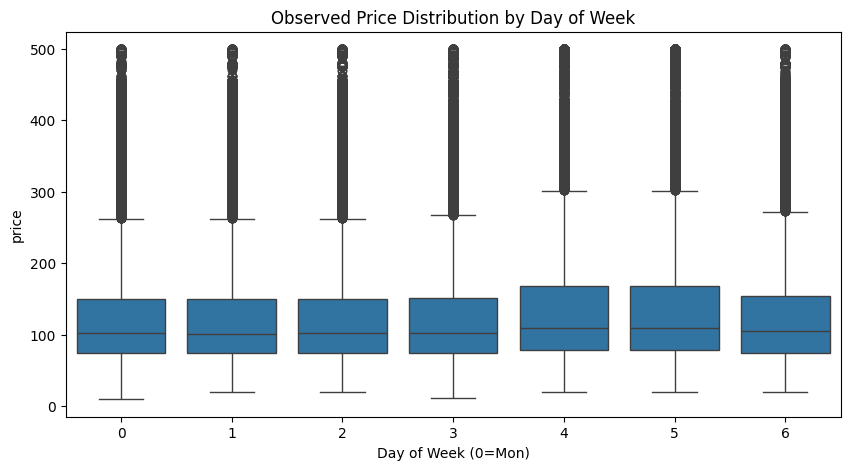

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='dow',
    y='price',
    data=df_clean[df_clean['action_observed'] & (df_clean['price'] < 500)]
)
plt.title("Observed Price Distribution by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.show()


In [ ]:
price_autocorr = (
    df_clean[df_clean['action_observed']]
    .groupby('listing_id')['price']
    .apply(lambda x: x.autocorr(lag=1))
)

print("Median price autocorrelation (lag 1):", price_autocorr.median())


c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\99sma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Median price autocorrelation (lag 1): 0.8178390692861297


In [ ]:
if (
    id_metrics['pct_identifiable'] >= auditor.thresh.min_variance_coverage
    and sparsity_metrics['pct_low_exposure'] < 0.8
):
    print("🟢 AUDIT PASSED: Market supports causal dynamic pricing.")
else:
    print("🔴 AUDIT FAILED: Data unsuitable for safe dynamic pricing.")


🟢 AUDIT PASSED: Market supports causal dynamic pricing.


In [16]:
# ============================================================
# Aggregated Identifiability Check (Weekly Resolution)
# ============================================================

# 1. Create a weekly index
df_weekly = df_clean.copy()
df_weekly['week'] = df_weekly['date'].dt.to_period('W').astype(str)

# 2. Aggregate to (listing_id, week)
weekly_panel = (
    df_weekly
    .groupby(['listing_id', 'week'])
    .agg(
        mean_price=('price', 'mean'),               # exposure
        exposure_days=('exposed', 'sum'),            # how many days price was visible
        booked_any=('is_booked_proxy', 'max'),       # did any booking/block occur
        booked_count=('is_booked_proxy', 'sum')      # intensity proxy
    )
    .reset_index()
)

# Keep only weeks with some price exposure
weekly_panel = weekly_panel[weekly_panel['exposure_days'] > 0]

print("Weekly panel rows:", len(weekly_panel))
print("Share of weeks with any booking:", weekly_panel['booked_any'].mean())


Weekly panel rows: 141080
Share of weeks with any booking: 0.07582931669974483


In [17]:
# ============================================================
# Aggregated Confounding / Slope Check
# ============================================================

def aggregated_demand_slope(df):
    tmp = df.copy()

    # Guardrails
    if tmp['mean_price'].nunique() < 5:
        return np.nan

    # Bin prices into quantiles
    tmp['price_bin'] = pd.qcut(tmp['mean_price'], q=5, duplicates='drop')

    rates = tmp.groupby('price_bin')['booked_any'].mean()

    if rates.nunique() < 2:
        return np.nan

    # Correlation between price rank and booking rate
    slope = np.corrcoef(range(len(rates)), rates)[0, 1]
    return slope

agg_slope = aggregated_demand_slope(weekly_panel)

print("Aggregated (weekly) price → booking slope:", agg_slope)


Aggregated (weekly) price → booking slope: -0.23808884256421117


C:\Users\99sma\AppData\Local\Temp\ipykernel_15476\1289851370.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = tmp.groupby('price_bin')['booked_any'].mean()
